<a href="https://colab.research.google.com/github/maellisrll-ui/Python-class-Session6-individual-assignment/blob/main/Inidividual_classwork_Maellis_Rivoallon_Le_Lous.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INDIVDUAL CLASSWORK - MAELLIS RIVOALLON LE LOUS

**TASK1 : DATA QUALITY ASSESSMENT**

In [21]:
import pandas as pd
import numpy as np

print("pandas version:", pd.__version__)

pandas version: 2.2.2


In [22]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

worksheet = gc.open('sales_data - Sheet1').sheet1

# get_all_values gives a list of rows.
rows = worksheet.get_all_values()
print(rows)

# Convert to a DataFrame and render.
import pandas as pd
pd.DataFrame.from_records(rows)

# Find the data types
df = pd.DataFrame(rows)
print(df.dtypes)
df.info()
df.describe()
df.describe(include="all")
df.shape
df.columns

# Columns with missing values
df.isnull().sum()

# Duplicated rows
df.duplicated().sum()

[['Order_ID', 'Date', 'Region', 'Sales_Channel', 'Customer_Segment', 'Product', 'Units_Sold', 'Unit_Price', 'Discount', 'Revenue', 'Country'], ['1001', '2026-01-03', 'North', 'Online', 'Consumer', 'Laptop', '2', '900', '0.1', '1620', 'France'], ['1002', '2026-01-04', 'South', 'Retail', 'Corporate', 'Phone', '4', '600', '0.05', '2280', 'France'], ['1003', '2026-01-05', 'north', 'online', 'Consumer', 'Tablet', '3', '350', '', '1050', 'France'], ['1004', '2026-01-05', 'West', 'ONLINE', 'Small Business', 'Monitor', '1', '0.2', '0', '1100', 'France'], ['1005', '2026-01-07', 'East', 'Retail', '', 'Laptop', '6', '950', '0.1', '855', 'France'], ['1006', '2026-01-08', 'North', 'Online', 'Consumer', 'Phone', '4', '650', '0.05', '3705', 'France'], ['1007', '2026-01-09', 'South', 'retail', 'Corporate', 'Tablet', '8', '320', '0', '1280', 'France'], ['1008', '2026-01-10', 'West', 'Online', 'Consumer', 'Monitor', '2', '250', '0.15', '1700', 'France'], ['1009', '2026-01-11', 'East', 'Retail', 'Corpora

np.int64(0)

QUESTIONS :
1. How many rows and columns? 100 rows × 11 columns
2. What are the data types? The data type for the 10 column is object
3. Which columns contain missing values? According to the code there are 0 non-null values. But from what I can see, there are missing values in Sales_channel, Customer_Segment, and Discount.
4. Are there duplicated rows? No, according to the code there are 0 duplicated rows

**TASK 2 : DATA CLEANING**

<Axes: xlabel='8'>

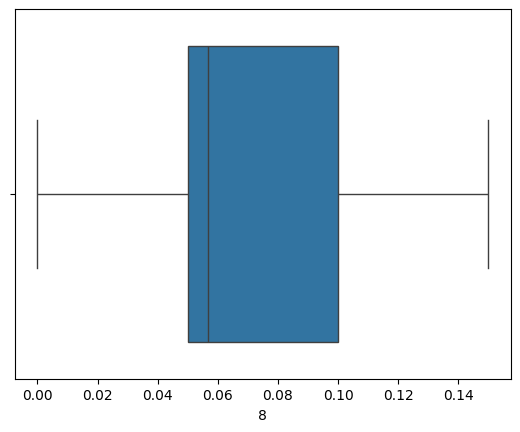

In [31]:
gc = gspread.authorize(creds)

worksheet = gc.open('sales_data - Sheet1').sheet1

# standardise categorical variables

# handle missing values
  # missing values are located in Sales_channel, Customer Segments (both are qualitative data), and discount (quantitative)
    #for the 2 qualitatives data, we will use the mode. And for the quantitative, we will use the mean.

# 'Discount' column is at index 8. First, convert it to numeric, coercing non-numeric values to NaN.
df[8] = pd.to_numeric(df[8], errors='coerce')

# Now, fill the NaN values with the mean of the numeric 'Discount' column.
df[8] = df[8].fillna(df[8].mean())

# Fill missing 'Sales_channel' (index 3) with its mode
df[3] = df[3].fillna(df[3].mode()[0])

# Fill missing 'Customer_Segment' (index 4) with its mode
df[4] = df[4].fillna(df[4].mode()[0])

# remove duplicates
df = df.drop_duplicates()

# remove non-informative columns
# The 'Country' column was at index 10, but it has already been dropped. Removing the redundant line.
df.columns

# handle outliers
df.describe()
import seaborn as sns
sns.boxplot(x=df[8])

QUESTION :

Are missing values concentrated in specific regions or products?
Yes missing values were find in 3 columns, 2 being qualitatives (Sales_Channel and Customer_Segments), and 1 being quantitative (Discount)

**TASK 3 : REVENUE ANALYSIS**

Text(0, 0.5, 'Total Revenue')

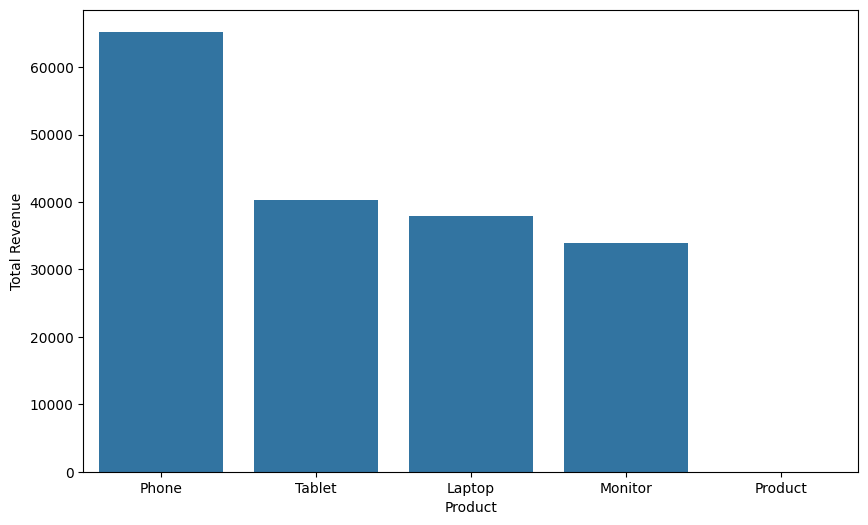

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Revenue' column (index 9) to numeric type, coercing errors to NaN
df[9] = pd.to_numeric(df[9], errors='coerce')

# Group by 'Product' (index 5) and sum 'Revenue' (index 9)
total_revenue_per_product = df.groupby(5)[9].sum().sort_values(ascending=False)

# Visualisation of bar chart of total revenue by product
plt.figure(figsize=(10, 6))
sns.barplot(x=total_revenue_per_product.index, y=total_revenue_per_product.values)
plt.xlabel('Product')
plt.ylabel('Total Revenue')

QUESTION :

Which product generated the highest total revenue? The product taht generated the highes total revenue is the Phone, then the Tablet, the Laptot Product and finally the monitor.

**TASK 4 : CUSTOMER BEHAVIOUR INSIGHTS**


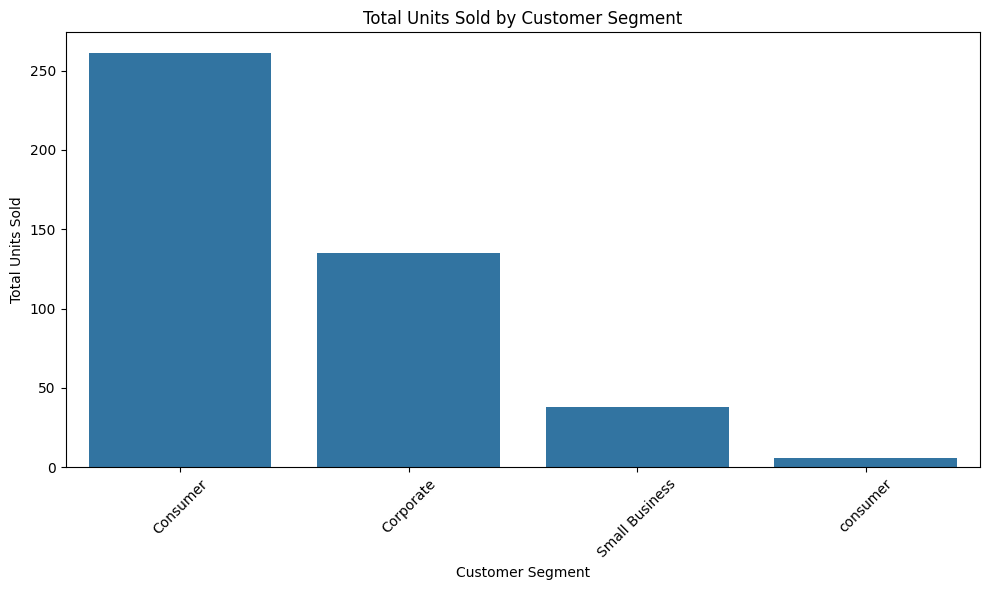

In [51]:
# We want to draw a graph between the customer segments and the units sold :

# Ensure 'Units_Sold' column (index 6) is numeric before summing
df[df.columns[6]] = pd.to_numeric(df[df.columns[6]], errors='coerce')

# Group by 'Customer_Segment' (index 4) and sum 'Units_Sold' (index 6)
units_sold_by_cs = df.groupby(df.columns[4])[df.columns[6]].sum().sort_values(ascending=False)


# Visualisation of bar chart of Customer Segment by Units Sold
plt.figure(figsize=(10, 6))
sns.barplot(x=units_sold_by_cs.index, y=units_sold_by_cs.values)
plt.xlabel('Customer Segment')
plt.ylabel('Total Units Sold')
plt.title('Total Units Sold by Customer Segment')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

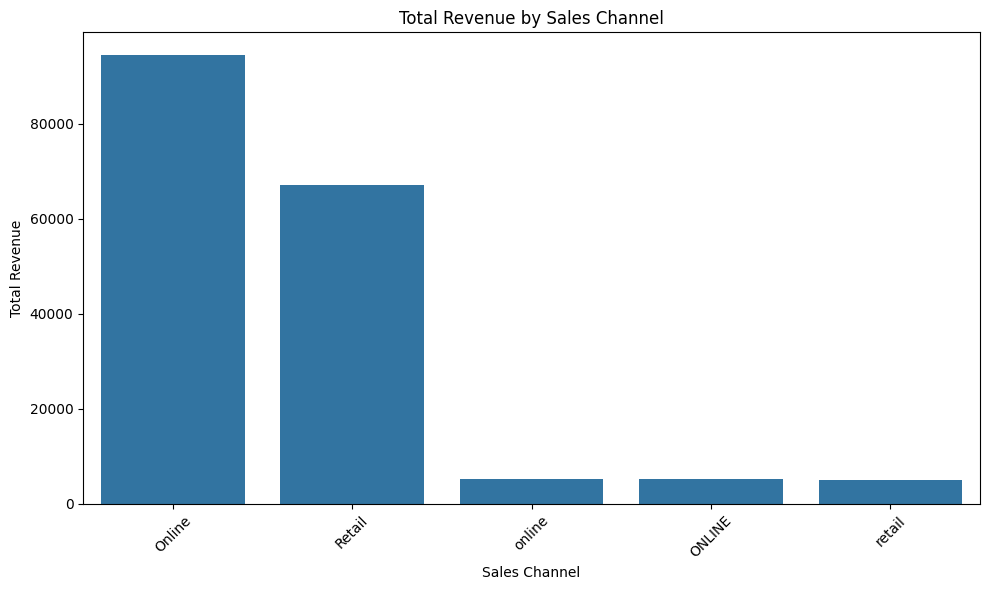

Text(0.5, 1.0, 'Count of Sales Channels')

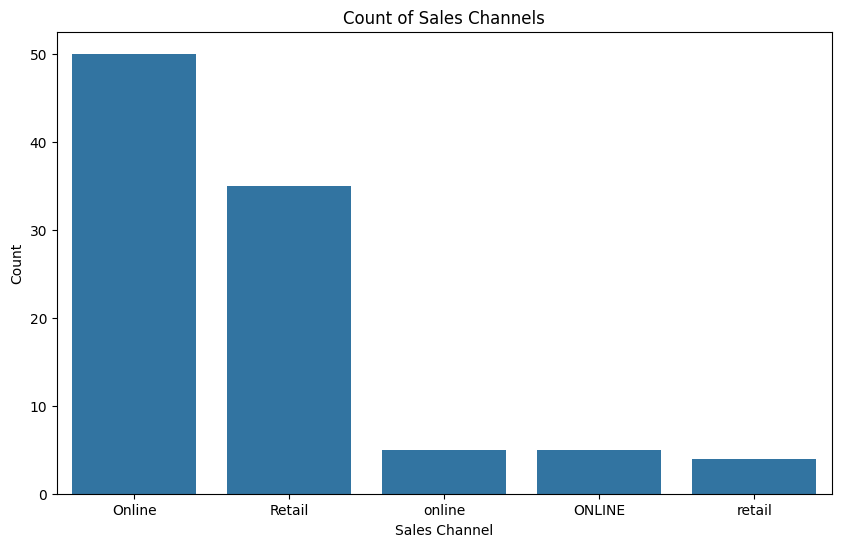

In [53]:
# We want to draw a graph between the sales channel and the revenue :

# Re-initialize df from rows to ensure original data is loaded
df = pd.DataFrame(rows)

# Assuming the first row is headers, set headers and remove it from data
df.columns = df.iloc[0]
df = df[1:].copy()

# Re-apply cleaning for 'Sales_Channel' (index 3):
# Fill missing 'Sales_Channel' with its mode (should not be numeric)
df[df.columns[3]] = df[df.columns[3]].replace('', np.nan) # Replace empty strings with NaN first
df[df.columns[3]] = df[df.columns[3]].fillna(df[df.columns[3]].mode()[0])


# Ensure 'Revenue' column (index 9) is numeric before summing
df[df.columns[9]] = pd.to_numeric(df[df.columns[9]], errors='coerce')

# Group by 'Sales_Channel' (index 3) and sum 'Revenue' (index 9)
total_revenue_per_channel = df.groupby(df.columns[3])[df.columns[9]].sum().sort_values(ascending=False)


# Visualisation of bar chart of Customer Segment by Units Sold
plt.figure(figsize=(10, 6))
sns.barplot(x=total_revenue_per_channel.index, y=total_revenue_per_channel.values)
plt.xlabel('Sales Channel')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Sales Channel')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Visualisation using a countplot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=df.columns[3])
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.title('Count of Sales Channels')

QUESTIONS :

1. Which customer segment buys the most units? Consumers segment is the one buying the most.
2. Does sales channel influence revenue? Yes, revenue is more important when the sales channel is online compared the retail sales channel.

**TASK 5 : REVENUE BY REGION**

<Axes: xlabel='Region'>

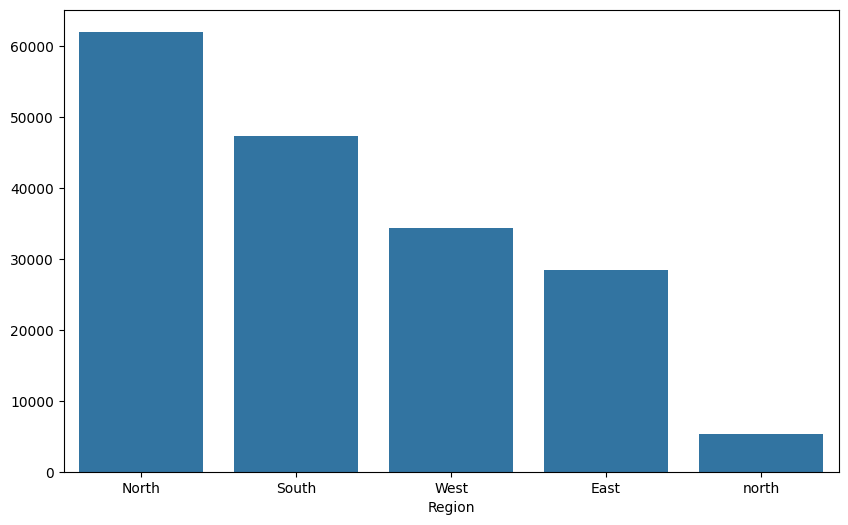

In [54]:
# Group by 'Region' (index 2) and sum 'Revenue' (index 9)
total_revenue_per_region = df.groupby(df.columns[2])[df.columns[9]].sum().sort_values(ascending=False)

# Visualisation of bar chart of Customer Segment by Units Sold
plt.figure(figsize=(10, 6))
sns.barplot(x=total_revenue_per_region.index, y=total_revenue_per_region.values)

QUESTION :

Which region generated the highest total revenue? The region with the highest total revenue is the North.

**TASK 6 : DISCOUNT IMPACT**

In [56]:
# Convert 'Discount' column to numeric, coercing errors to NaN
df["Discount"] = pd.to_numeric(df["Discount"], errors='coerce')

# Fill any NaN values in 'Discount' with the column's mean to ensure it's fully numeric
df["Discount"] = df["Discount"].fillna(df["Discount"].mean())

# Ensure 'Revenue' column is numeric (it should have been cleaned by a previous cell)
df["Revenue"] = pd.to_numeric(df["Revenue"], errors='coerce')

corr = df[["Discount", "Revenue"]].corr()

print(corr)

0         Discount   Revenue
0                           
Discount  1.000000 -0.102446
Revenue  -0.102446  1.000000


QUESTION :

Does a higher discount lead to higher revenue? The correlation is negative between the 2 variables, therefore they move in opposite direction. A higher discount leads to lower revenue.

**TASK 7 : PRODUCT POPULARITY**

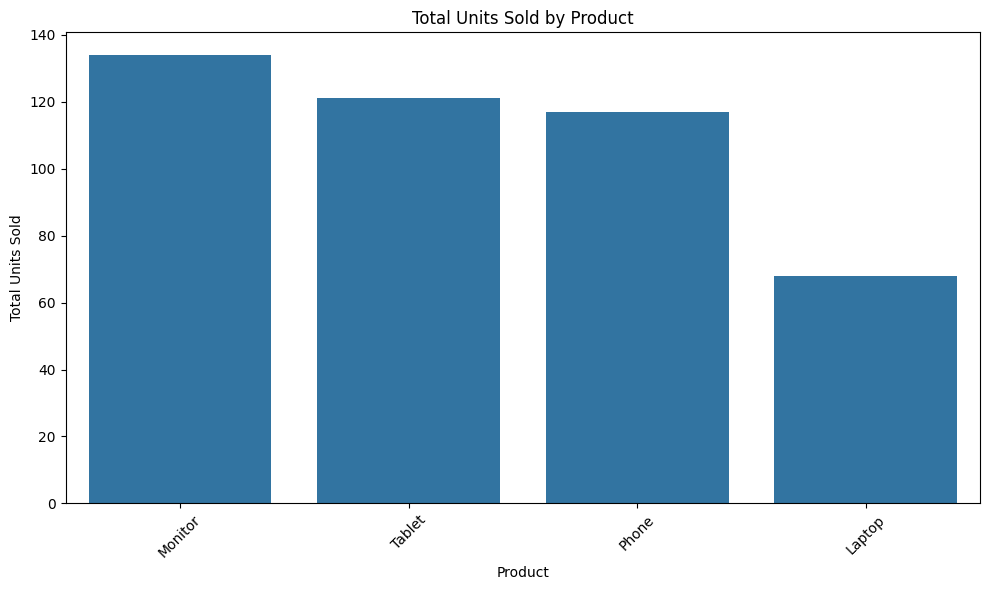

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Revenue' column to numeric type, coercing errors to NaN
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

# Ensure 'Units_Sold' column is numeric
df['Units_Sold'] = pd.to_numeric(df['Units_Sold'], errors='coerce')

# Group by 'Product' and sum 'Units_Sold'
unit_sold_per_product = df.groupby('Product')['Units_Sold'].sum().sort_values(ascending=False)

# Visualisation of bar chart of total units sold by product
plt.figure(figsize=(10, 6))
sns.barplot(x=unit_sold_per_product.index, y=unit_sold_per_product.values)
plt.xlabel('Product')
plt.ylabel('Total Units Sold')
plt.title('Total Units Sold by Product')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

QUESTIONS :

1. Which product sold the largest number of units? The Product zith the largest number of units sold is the Monitor.

2. Is the most product also the most profitable? No because earlier, we found that the monitor was the category of product that was earning the least revenues (in Task 3).

**TASK 8 : MONTHLY SALES TREND**

Text(0.5, 1.0, 'Monthly Revenue Trend')

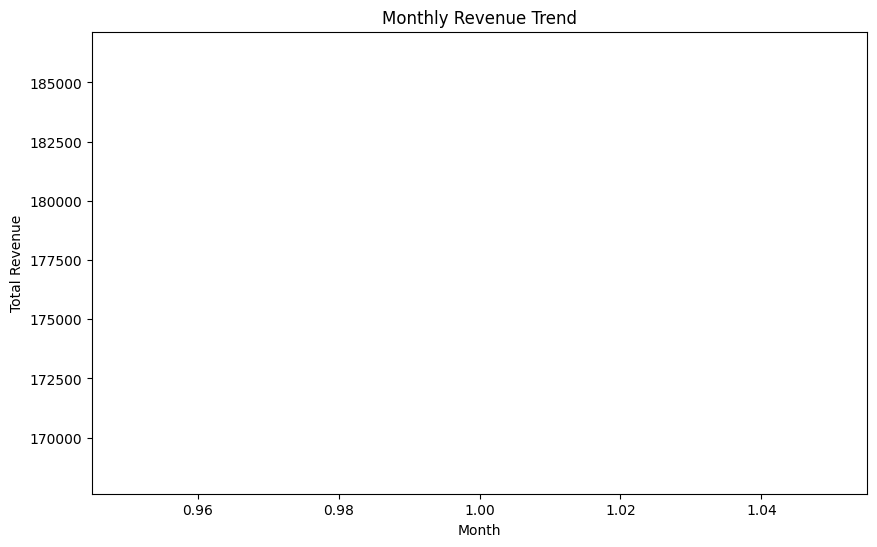

In [63]:
df["Date"] = pd.to_datetime(df["Date"])

monthly = (
    df.groupby(df["Date"].dt.month)
    ["Revenue"]
    .sum()
)

# Visualisation of revenue over time using a line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly.index, y=monthly.values)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Revenue Trend')

QUESTION :

How does revenue change over time ? I'm sorry I don't know because my code doesn't work, and I can't find find how to fix it. However, I suppose that revenue must grow over time, in a linear way.

**TASK 9 : REVENUE DISTRIBUTION**

Text(0.5, 1.0, 'Distribution of Revenue')

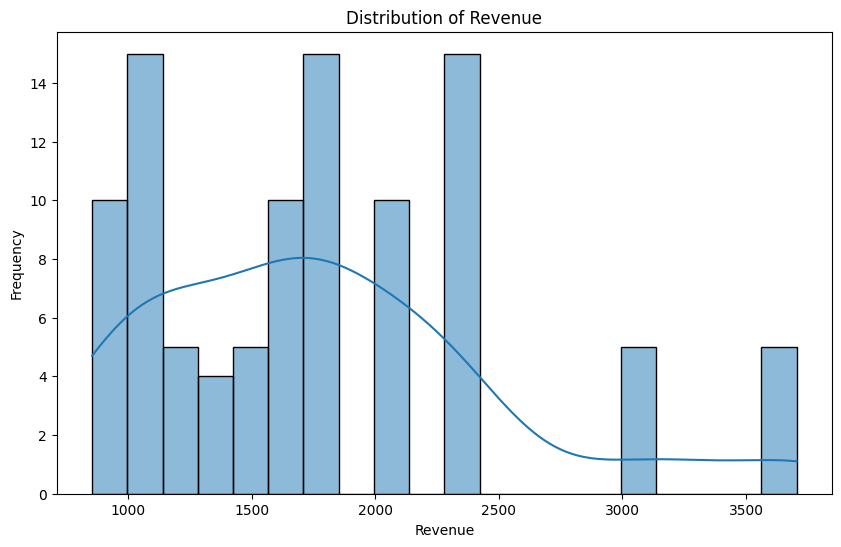

In [65]:
df["Revenue"].describe()

# Visualisation of the distribution of revenue using a histogram ?
plt.figure(figsize=(10, 6))
sns.histplot(df["Revenue"], bins=20, kde=True)
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.title('Distribution of Revenue')

QUESTION :

Is revenue normally distributed ? No, the revenue is not normally distributed, we can see the irregular pattern with a right tail skewness.

**TASK 10 : ADVANCED (NOT REQUIRED)**

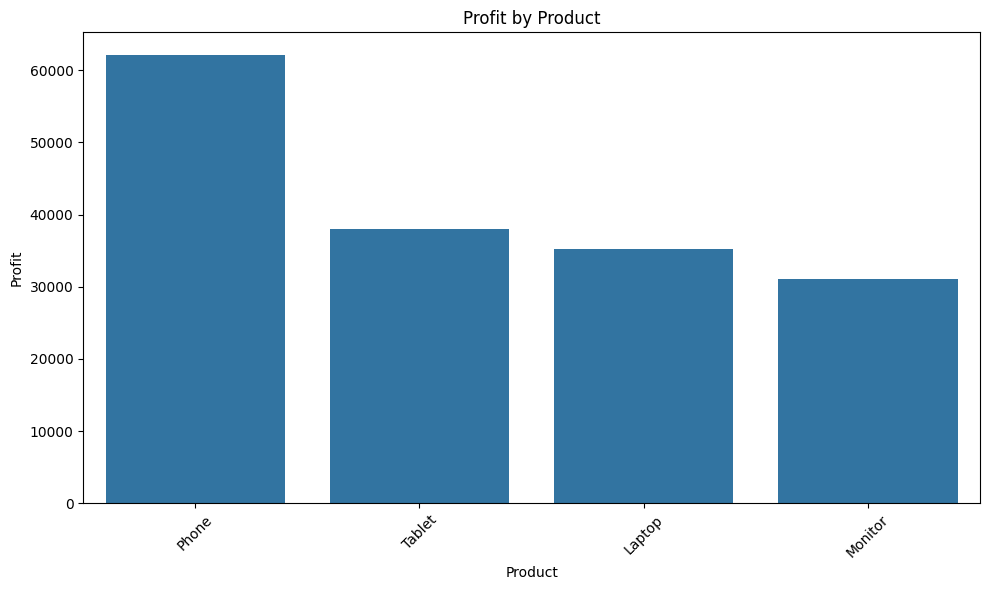

In [69]:
# Creating a new column for Profits
df["Profit"] = df["Revenue"] * (1 - df["Discount"])

# Group by 'Product' and sum 'Profit'
profits_per_product = df.groupby('Product')['Profit'].sum().sort_values(ascending=False)

# Visualisation of bar chart of profits sold by product
plt.figure(figsize=(10, 6))
sns.barplot(x=profits_per_product.index, y=profits_per_product.values)
plt.xlabel('Product')
plt.ylabel('Profit')
plt.title('Profit by Product')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

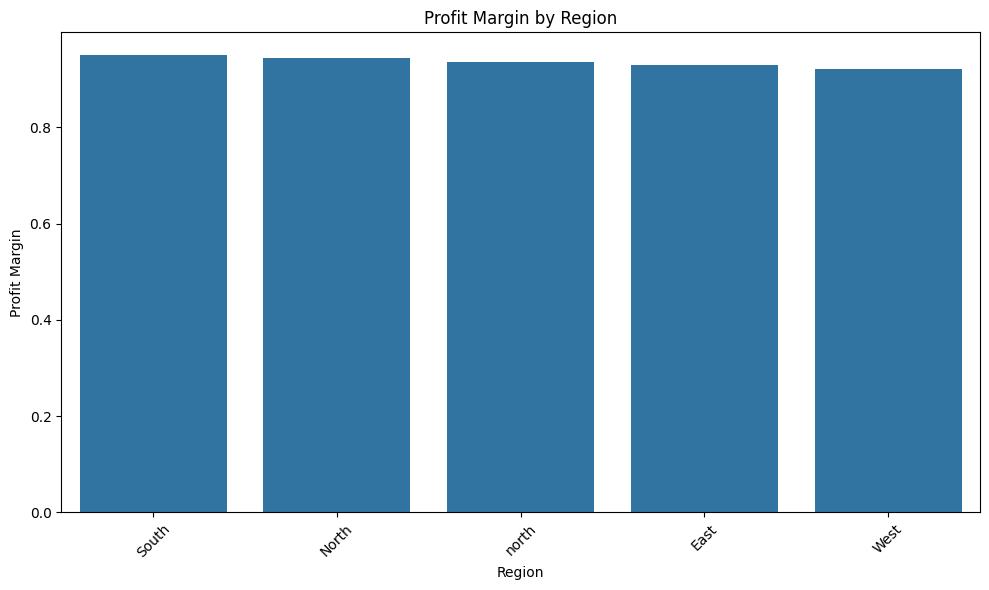

In [70]:
# Creating a new column for Profit_Margin
df["Profit_Margin"] = df["Profit"] / df["Revenue"]

# Group by 'Region' and calculate the mean of 'Profit_Margin'
profit_margin_per_product = df.groupby('Region')['Profit_Margin'].mean().sort_values(ascending=False)

# Visualisation of bar chart of profit margin by region
plt.figure(figsize=(10, 6))
sns.barplot(x=profit_margin_per_product.index, y=profit_margin_per_product.values)
plt.xlabel('Region')
plt.ylabel('Profit Margin')
plt.title('Profit Margin by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
# Convert 'Discount' column to numeric, coercing errors to NaN
df["Discount"] = pd.to_numeric(df["Discount"], errors='coerce')

# Fill any NaN values in 'Discount' with the column's mean to ensure it's fully numeric
df["Discount"] = df["Discount"].fillna(df["Discount"].mean())

# Ensure 'Profit' column is numeric (it should have been cleaned by a previous cell)
df["Profit"] = pd.to_numeric(df["Profit"], errors='coerce')

corr = df[["Discount", "Profit"]].corr()

print(corr)

0         Discount    Profit
0                           
Discount  1.000000 -0.197165
Profit   -0.197165  1.000000


QUESTIONS :

1. Which product has the highest profit? The phone product has the highest profit.
2. Which region has the best profit margin? Apparently they seem to have the same profit margin. There must be an error in my code.

3. Does discount increase or decrease profit? Given the negative correlation, the discount decrease the profit (they move in opposite directions).

Finished on the 22nd June.
Student Name : Maëllis Rivoallon Le Lous
Student Class : 4A DSBI

We have a Workspace Extension, [Sheets to Colab](https://workspace.google.com/u/0/marketplace/app/sheets_to_colab/945625412720), which allows you to directly import data from Google Sheets into Colab from the Sheets UI. Follow the link to learn more.